# Phần 1: Nền Tảng Lý Thuyết

Notebook này trình bày toàn bộ quy trình **Phần 1** của project theo thứ tự logic từ lý thuyết đến thực nghiệm: xây dựng mô hình OLS từ phương trình pháp tuyến, tính hat matrix và kiểm chứng các tính chất hình học của nó, suy luận thống kê trên hệ số hồi quy, đánh giá mô hình bằng các chỉ số và chẩn đoán phần dư, chuẩn hóa Ridge và Lasso theo phương pháp coordinate descent, cross-validation để chọn siêu tham số, và mô phỏng Monte Carlo kiểm chứng Định lý Gauss--Markov.

In [32]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PART1 = Path('.')
if str(PART1) not in sys.path:
    sys.path.insert(0, str(PART1))

from ols_implementation       import ols_fit, hat_matrix
from inference                import coef_inference, vif
from model_evaluation         import model_metrics, residual_plots
from regularization           import ridge_fit, ridge_trace, lasso_fit, lasso_path
from cross_validation         import kfold_cv, kfold_cv_ridge, model_selection_cv, _random_k_fold
from monte_carlo_gauss_markov import run_monte_carlo


---
## 1. Bài Toán OLS và Normal Equations

Cho tập quan sát $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$ với $\mathbf{x}_i \in \mathbb{R}^p$ và $y_i \in \mathbb{R}$, hãy tìm hàm tuyến tính $f(\mathbf{x}) = \mathbf{x}^\top \boldsymbol{\beta}$ sao cho tổng bình phương sai lệch $\text{RSS}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2$ đạt giá trị nhỏ nhất.

Đây là bài toán tối thiểu hóa lồi không ràng buộc, nghiệm tối ưu tìm được bằng cách đặt gradient bằng không, dẫn đến hệ **Normal Equations**:

$$( \mathbf{X}^\top \mathbf{X} )\hat{\boldsymbol{\beta}} = \mathbf{X}^\top \mathbf{y}.$$

Khi $\mathbf{X}^\top \mathbf{X}$ khả nghịch, nghiệm dạng đóng là $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1}\mathbf{X}^\top \mathbf{y}$. Implementation trong `ols_fit` giải hệ này bằng Gauss-Jordan thay vì dùng `np.linalg.solve`, đảm bảo không phụ thuộc vào thư viện số học bên ngoài cho phần thuật toán chính.

In [33]:
np.random.seed(2024)
n, p = 80, 3
X_np = np.column_stack([np.ones(n), np.random.randn(n, p)])
beta_true = np.array([0.5, 1.5, -0.8, 2.1])
y_np = X_np @ beta_true + np.random.randn(n) * 0.5

X = X_np.tolist()
y = y_np.tolist()

print(f'Ma tran thiet ke X: {len(X)} hang x {len(X[0])} cot  (cot 0 = intercept)')
print(f'Beta thuc su      : {beta_true.tolist()}')


Ma tran thiet ke X: 80 hang x 4 cot  (cot 0 = intercept)
Beta thuc su      : [0.5, 1.5, -0.8, 2.1]


In [34]:
result = ols_fit(X, y)

print(result.message)
print()
header = f"  {'Bien':>12}  {'beta_hat':>10}  {'beta_true':>10}  {'sai lech':>10}"
print(header)
print('  ' + '-' * (len(header) - 2))
labels = ['intercept'] + [f'x{j}' for j in range(1, p + 1)]
for j, lbl in enumerate(labels):
    print(f"  {lbl:>12}  {result.beta_hat[j]:>10.4f}  {beta_true[j]:>10.4f}  {result.beta_hat[j] - beta_true[j]:>+10.4f}")
print()
print(f'sigma^2_hat = {result.sigma2_hat:.4f}  (that su: {0.5**2:.4f})')
print(f'RSS         = {result.rss:.4f}')
print(f'DOF         = n - p - 1 = {result.dof}')
print(f'Thoi gian   = {result.runtime_sec * 1000:.2f} ms')


Solved. RSS=21.351, sigma2=0.280934, dof=76.

          Bien    beta_hat   beta_true    sai lech
  ------------------------------------------------
     intercept      0.3853      0.5000     -0.1147
            x1      1.5330      1.5000     +0.0330
            x2     -0.8358     -0.8000     -0.0358
            x3      2.0900      2.1000     -0.0100

sigma^2_hat = 0.2809  (that su: 0.2500)
RSS         = 21.3510
DOF         = n - p - 1 = 76
Thoi gian   = 0.86 ms


### 1.1. Hat Matrix và Tính Chất Hình Học

**Hat matrix** $\mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$ là phép chiếu trực giao lên không gian cột $\mathcal{C}(\mathbf{X})$, thỏa mãn $\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$.

Vì là phép chiếu trực giao, $\mathbf{H}$ có hai tính chất đại số bắt buộc: (1) **đối xứng** $\mathbf{H} = \mathbf{H}^\top$; (2) **idempotent** $\mathbf{H}^2 = \mathbf{H}$ vì chiếu hai lần bằng chiếu một lần. Ngoài ra $\text{rank}(\mathbf{H}) = \text{tr}(\mathbf{H}) = p + 1$ vì các trị riêng của $\mathbf{H}$ chỉ nhận giá trị 0 hoặc 1.

In [35]:
hm = hat_matrix(X)
print(hm.message)
print()

H_scratch = np.array(hm.H)
H_numpy   = X_np @ np.linalg.inv(X_np.T @ X_np) @ X_np.T
print(f'Sai so cuc dai |H_scratch - H_numpy| : {np.max(np.abs(H_scratch - H_numpy)):.2e}')
print(f'rank(H)        = {hm.rank_H}   (ky vong p+1 = {len(X[0])})')
print(f'trace(H)       = {hm.trace_H:.4f}  (ky vong p+1 = {len(X[0])})')
print(f'||H^2 - H||_F  = {hm.idem_err:.2e}  (ky vong < 1e-10)')
print(f'||H - H^T||_inf= {hm.sym_err:.2e}  (ky vong < 1e-10)')


[OK] ||H^2-H||_F=1.90e-16, ||H-H^T||_inf=2.78e-17, rank=4 (exp 4), tr=4.0000 (exp 4).

Sai so cuc dai |H_scratch - H_numpy| : 6.94e-17
rank(H)        = 4   (ky vong p+1 = 4)
trace(H)       = 4.0000  (ky vong p+1 = 4)
||H^2 - H||_F  = 1.90e-16  (ky vong < 1e-10)
||H - H^T||_inf= 2.78e-17  (ky vong < 1e-10)


---
## 2. Suy Luận Thống Kê

Dưới giả thiết $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$, ước lượng OLS thỏa mãn $\hat{\boldsymbol{\beta}} \sim \mathcal{N}(\boldsymbol{\beta}, \sigma^2 (\mathbf{X}^\top\mathbf{X})^{-1})$. Sai số chuẩn của hệ số thứ $j$ là $\text{se}(\hat{\beta}_j) = \hat{\sigma} \sqrt{[(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj}}$, và thống kê kiểm định $t_j = \hat{\beta}_j / \text{se}(\hat{\beta}_j)$ tuân theo phân phối Student-$t$ với $n - p - 1$ bậc tự do dưới giả thuyết không $H_0: \beta_j = 0$. Giá trị $p$-value và khoảng tin cậy $(1-\alpha)\%$ được tính từ đầu thông qua hàm beta không đầy đủ chuẩn hóa, không phụ thuộc scipy.

**VIF** (Variance Inflation Factor) đo mức độ đa cộng tuyến của biến $j$:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

trong đó $R^2_j$ là hệ số xác định khi hồi quy biến $X_j$ lên tất cả biến còn lại. $\text{VIF}_j > 10$ là ngưỡng cảnh báo đa cộng tuyến nghiêm trọng.

In [36]:
ci = coef_inference(X, y, beta_hat=result.beta_hat, sigma2=result.sigma2_hat, alpha=0.05)

header = f"  {'Bien':>12}  {'beta_hat':>10}  {'se':>8}  {'t-stat':>8}  {'p-value':>9}  CI 95%"
print(header)
print('  ' + '-' * 72)
for j, lbl in enumerate(['intercept'] + [f'x{k}' for k in range(1, p + 1)]):
    sig = '*' if ci.p_values[j] < 0.05 else ' '
    print(f"{sig} {lbl:>12}  {ci.coefficients[j]:>10.4f}  "
          f"{ci.std_errors[j]:>8.4f}  {ci.t_statistics[j]:>8.3f}  "
          f"{ci.p_values[j]:>9.4f}  [{ci.ci_lower[j]:.3f}, {ci.ci_upper[j]:.3f}]")
print('  (* p < 0.05)')


          Bien    beta_hat        se    t-stat    p-value  CI 95%
  ------------------------------------------------------------------------
*    intercept      0.3853    0.0595     6.477     0.0000  [0.267, 0.504]
*           x1      1.5330    0.0567    27.046     0.0000  [1.420, 1.646]
*           x2     -0.8358    0.0613   -13.632     0.0000  [-0.958, -0.714]
*           x3      2.0900    0.0576    36.307     0.0000  [1.975, 2.205]
  (* p < 0.05)


In [37]:
vif_result = vif(X)

print('Variance Inflation Factors (cot 0 = intercept, khong co y nghia VIF):')
print(f"  {'Bien':>8}  {'VIF':>8}  {'Canh bao'}")
print('  ' + '-' * 35)
for name, score in zip(vif_result.column_names, vif_result.vif_values):
    flag = 'COLLINEAR' if isinstance(score, float) and score > 10.0 else ''
    score_str = f'{score:.3f}' if isinstance(score, float) and score < 1e6 else 'inf'
    print(f"  {name:>8}  {score_str:>8}  {flag}")
print()
print(f'Max VIF = {vif_result.max_vif:.3f},  da cong tuyen: {vif_result.has_multicollinearity}')


Variance Inflation Factors (cot 0 = intercept, khong co y nghia VIF):
      Bien       VIF  Canh bao
  -----------------------------------
        X0       inf  
        X1     1.007  
        X2     1.011  
        X3     1.004  

Max VIF = 1.011,  da cong tuyen: False


---
## 3. Đánh Giá Mô Hình và Chẩn Đoán Phần Dư

Sau khi ước lượng $\hat{\boldsymbol{\beta}}$, chất lượng mô hình được đo bằng bốn chỉ số cơ bản: RSS, MSE, RMSE và hệ số xác định $R^2 = 1 - \text{RSS}/\text{TSS}$. Lưu ý rằng $R^2$ không giảm khi thêm biến vào mô hình, nên $R^2_{\text{adj}}$ điều chỉnh theo bậc tự do $n - p - 1$ được dùng để so sánh giữa các mô hình có độ phức tạp khác nhau. Ngoài ra, F-statistic kiểm định đồng thời giả thuyết $H_0: \beta_1 = \ldots = \beta_p = 0$, tức là mô hình không có biến giải thích nào có ý nghĩa.

Chẩn đoán phần dư kiểm tra bốn giả thiết Gauss-Markov: (1) phần dư có kỳ vọng bằng không, (2) phương sai đồng nhất (homoscedasticity), (3) không tự tương quan, (4) phân phối chuẩn qua biểu đồ Q-Q.

In [38]:
metrics = model_metrics(y, result.y_hat, p=len(X[0]) - 1)

print(f'RSS         = {metrics.rss:.4f}')
print(f'MSE         = {metrics.rss / len(y):.4f}')
print(f'RMSE        = {metrics.rmse:.4f}')
print(f'R^2         = {metrics.r2:.4f}')
print(f'R^2_adj     = {metrics.r2_adj:.4f}')
print(f'F-statistic = {metrics.f_statistic:.4f}')
print(f'F p-value   = {metrics.f_pvalue:.4e}')


RSS         = 21.3510
MSE         = 0.2669
RMSE        = 0.5300
R^2         = 0.9670
R^2_adj     = 0.9657
F-statistic = 741.6881
F p-value   = 3.6067e-56


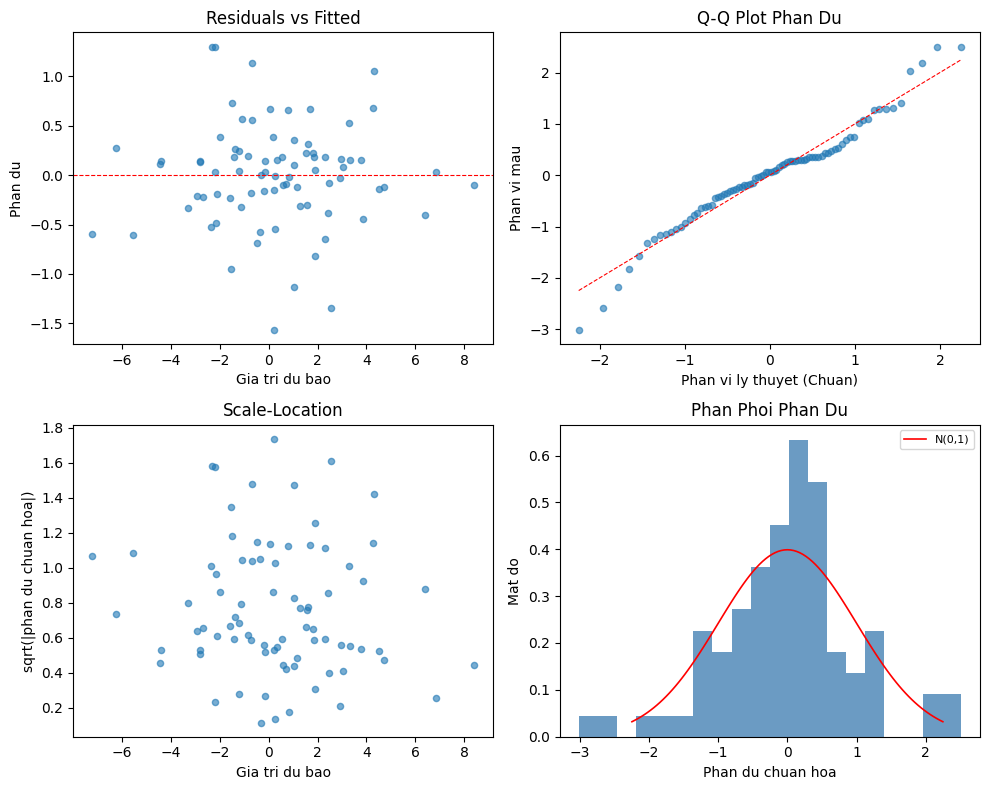

In [39]:
import math

rpd = residual_plots(X, y, result.beta_hat)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (1) Residuals vs Fitted
axes[0, 0].scatter(rpd.fitted_values, rpd.residuals, alpha=0.6, s=20)
axes[0, 0].axhline(0, color='red', linewidth=0.8, linestyle='--')
axes[0, 0].set_xlabel('Gia tri du bao')
axes[0, 0].set_ylabel('Phan du')
axes[0, 0].set_title('Residuals vs Fitted')

# (2) Q-Q plot
theo_q, sample_q = rpd.qqplot_data
axes[0, 1].scatter(theo_q, sample_q, alpha=0.6, s=20)
mn, mx = min(theo_q), max(theo_q)
axes[0, 1].plot([mn, mx], [mn, mx], 'r--', linewidth=0.8)
axes[0, 1].set_xlabel('Phan vi ly thuyet (Chuan)')
axes[0, 1].set_ylabel('Phan vi mau')
axes[0, 1].set_title('Q-Q Plot Phan Du')

# (3) Scale-Location
sqrt_std_resid = [math.sqrt(abs(e)) for e in rpd.standardized_residuals]
axes[1, 0].scatter(rpd.fitted_values, sqrt_std_resid, alpha=0.6, s=20)
axes[1, 0].set_xlabel('Gia tri du bao')
axes[1, 0].set_ylabel('sqrt(|phan du chuan hoa|)')
axes[1, 0].set_title('Scale-Location')

# (4) Histogram phan du chuan hoa
axes[1, 1].hist(rpd.standardized_residuals, bins=20, edgecolor='none',
                color='steelblue', alpha=0.8, density=True)
z_grid = [mn + (mx - mn) * i / 100 for i in range(101)]
normal_pdf = [math.exp(-z**2 / 2) / math.sqrt(2 * math.pi) for z in z_grid]
axes[1, 1].plot(z_grid, normal_pdf, 'r-', linewidth=1.2, label='N(0,1)')
axes[1, 1].set_xlabel('Phan du chuan hoa')
axes[1, 1].set_ylabel('Mat do')
axes[1, 1].set_title('Phan Phoi Phan Du')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Ridge Regression

Ridge Regression (Hoerl & Kennard, 1970) bổ sung penalty L2 vào hàm mất mát OLS:

$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = \arg\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \sum_{j=1}^p \beta_j^2.$$

Nghiệm dạng đóng là $\hat{\boldsymbol{\beta}}_\lambda = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{D})^{-1}\mathbf{X}^\top\mathbf{y}$, trong đó $\mathbf{D}$ là ma trận đường chéo với $D_{00} = 0$ (hệ số tự do không bị phạt) và $D_{jj} = 1$ với $j \geq 1$. Khi $\lambda \to 0$ nghiệm hội tụ về OLS; khi $\lambda \to \infty$ tất cả hệ số co về không. Ridge trace — đồ thị hệ số theo $\lambda$ — giúp quan sát sự co hẹp và chọn $\lambda$ tại điểm mà hệ số bắt đầu ổn định.

In [40]:
print(f"  {'lambda':>8}  {'RSS':>10}  {'penalty L2':>12}  {'total_loss':>12}")
print('  ' + '-' * 48)
for lam in [0.01, 0.1, 1.0, 10.0, 100.0]:
    r = ridge_fit(X, y, lam)
    print(f"  {lam:>8.2f}  {r.rss:>10.4f}  {r.ridge_penalty:>12.4f}  {r.total_loss:>12.4f}")


    lambda         RSS    penalty L2    total_loss
  ------------------------------------------------
      0.01     21.3510        7.4153       21.4252
      0.10     21.3519        7.3994       22.0918
      1.00     21.4371        7.2438       28.6809
     10.00     28.3914        5.9251       87.6425
    100.00    205.3304        1.5509      360.4187


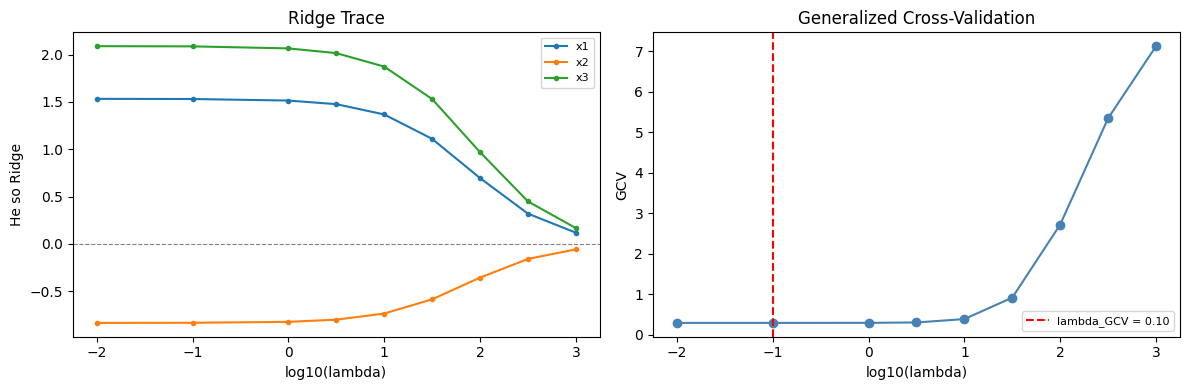

In [41]:
lam_grid = [10**x for x in [-2, -1, 0, 0.5, 1, 1.5, 2, 2.5, 3]]
trace = ridge_trace(X, y, lam_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

betas = np.array(trace.coefficients_trace)  # shape (n_lambda, p+1)
log_lams = np.log10(trace.lambdas)
for j in range(1, betas.shape[1]):
    axes[0].plot(log_lams, betas[:, j], marker='o', markersize=3, label=f'x{j}')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('log10(lambda)')
axes[0].set_ylabel('He so Ridge')
axes[0].set_title('Ridge Trace')
axes[0].legend(fontsize=8)

axes[1].plot(log_lams, trace.gcv_trace, 'o-', color='steelblue')
best_idx = int(np.argmin(trace.gcv_trace))
axes[1].axvline(log_lams[best_idx], color='red', linestyle='--',
                label=f'lambda_GCV = {trace.lambdas[best_idx]:.2f}')
axes[1].set_xlabel('log10(lambda)')
axes[1].set_ylabel('GCV')
axes[1].set_title('Generalized Cross-Validation')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## 5. Lasso Regression

Lasso (Tibshirani, 1996) thay penalty L2 của Ridge bằng penalty L1, tạo ra tính **thưa** (sparsity) trong nghiệm:

$$\hat{\boldsymbol{\beta}}_{\text{lasso}} = \arg\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \lambda \sum_{j=1}^p |\beta_j|.$$

Vì penalty L1 không khả vi tại $\beta_j = 0$, không tồn tại nghiệm dạng đóng. Thuật toán **coordinate descent** giải bài toán này bằng cách lần lượt tối ưu hóa từng hệ số $\beta_j$ trong khi giữ cố định các hệ số còn lại, áp dụng toán tử **soft-thresholding**:

$$S(z, \gamma) = \text{sign}(z)\max(|z| - \gamma, 0).$$

Mỗi iteration cập nhật $\hat{\beta}_j \leftarrow S(\rho_j / z_j,\; \lambda / 2z_j)$ với $\rho_j = \mathbf{X}_j^\top \mathbf{r}^{(-j)}$ là tích trong của cột $j$ với partial residual, và $z_j = \|\mathbf{X}_j\|_2^2$.

In [42]:
lasso_r = lasso_fit(X, y, lam=1.0)
print(lasso_r.message)
print()
print(f"  {'j':>3}  {'beta_j':>10}  {'|beta_j|':>10}")
print('  ' + '-' * 28)
for j, b in enumerate(lasso_r.coefficients):
    flag = '  <- zero' if abs(b) < 1e-8 else ''
    print(f"  {j:>3}  {b:>10.4f}  {abs(b):>10.4f}{flag}")
print()
print(f'He so khac 0: {lasso_r.nonzero_coef}/{len(X[0]) - 1} bien')
print(f'Hoi tu      : {lasso_r.converged}  ({lasso_r.n_iter} iterations)')


Lasso converged in 6 iter. nonzero=3/3

    j      beta_j    |beta_j|
  ----------------------------
    0      0.3847      0.3847
    1      1.5268      1.5268
    2     -0.8290      0.8290
    3      2.0845      2.0845

He so khac 0: 3/3 bien
Hoi tu      : True  (6 iterations)


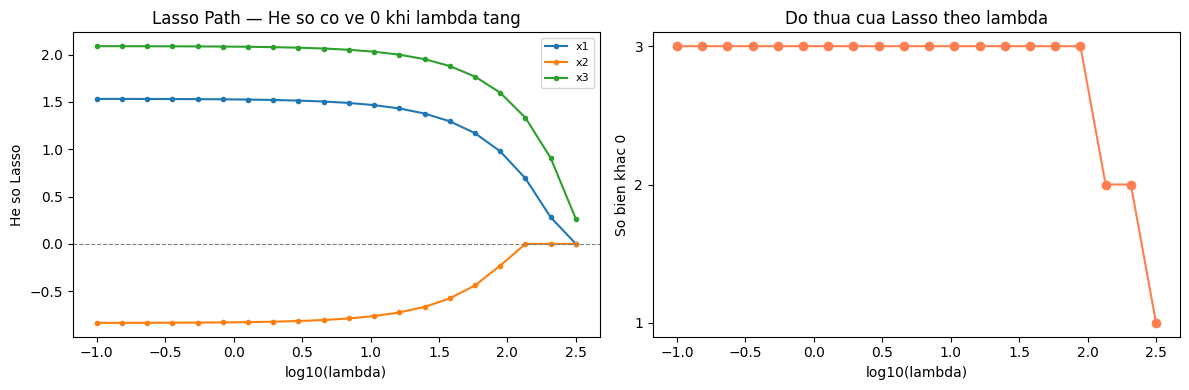

Lambda tai do tung bien bien mat:
  x1: lambda = 316.23  (log10 = 2.50)
  x2: lambda = 316.23  (log10 = 2.50)


In [43]:
import numpy as np

# Lambda phai du lon de co he so ve 0.
# Voi X chuẩn (||X_j||^2 ~ n=80) va beta_j ~ 2, nguong zeroing ~ 2 * X_j' * residual ~ 160.
# Dung logspace de phu day dai tu nho toi lon.
lam_path_vals = sorted(np.logspace(-1, 2.5, 20).tolist(), reverse=True)
path = lasso_path(X, y, lam_path_vals)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coef_arr = np.array(path.coefficients)   # shape (n_lambda, p+1)
log_lams_path = np.log10(path.lambdas)

for j in range(1, coef_arr.shape[1]):
    axes[0].plot(log_lams_path, coef_arr[:, j], marker='o', markersize=3, label=f'x{j}')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('log10(lambda)')
axes[0].set_ylabel('He so Lasso')
axes[0].set_title('Lasso Path — He so co ve 0 khi lambda tang')
axes[0].legend(fontsize=8)

axes[1].plot(log_lams_path, path.nonzero_counts, 'o-', color='coral')
axes[1].set_xlabel('log10(lambda)')
axes[1].set_ylabel('So bien khac 0')
axes[1].set_title('Do thua cua Lasso theo lambda')
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

# In nguong lambda tai do he so bat dau ve 0
print('Lambda tai do tung bien bien mat:')
for j in range(1, coef_arr.shape[1]):
    for idx, val in enumerate(coef_arr[:, j]):
        if abs(val) < 1e-8:
            print(f'  x{j}: lambda = {path.lambdas[idx]:.2f}  (log10 = {log_lams_path[idx]:.2f})')
            break

---
## 6. Cross-Validation và Lựa Chọn Siêu Tham Số

**K-fold cross-validation** đánh giá khả năng tổng quát hóa của mô hình bằng cách chia dữ liệu thành $k$ phần bằng nhau, lần lượt dùng mỗi phần làm tập test trong khi $k-1$ phần còn lại làm tập train, rồi lấy trung bình metric qua $k$ fold. Nguyên tắc cốt lõi là tập test của mỗi fold phải **hoàn toàn không được nhìn thấy** trong quá trình fit — bao gồm cả việc chọn siêu tham số — vì nếu không metric sẽ lạc quan do data leakage.

Để so sánh các mô hình công bằng, các fold được tạo một lần duy nhất và truyền vào từng hàm CV. Cách làm này đảm bảo mỗi mô hình được đánh giá trên đúng cùng tập test, loại bỏ nhiễu do phân chia ngẫu nhiên khác nhau giữa các lần gọi.

In [44]:
k = 5
shared_folds = _random_k_fold(len(y), k, random_state=42)

ols_cv = kfold_cv(X, y, k=k, metric='rmse', fold_indices=shared_folds)
print(f'OLS CV RMSE: {ols_cv.mean_cv_score:.4f}  +/-  {ols_cv.std_cv_score:.4f}')
print()
print(f"  {'lambda':>8}  {'CV RMSE':>10}  {'Std':>8}")
print('  ' + '-' * 32)
for lam in [0.01, 0.1, 1.0, 10.0, 100.0]:
    r = kfold_cv_ridge(X, y, lam=lam, k=k, metric='rmse',
                        fold_indices=[f[:] for f in shared_folds])
    print(f"  {lam:>8.2f}  {r.mean_cv_score:>10.4f}  {r.std_cv_score:>8.4f}")


OLS CV RMSE: 0.5368  +/-  0.0972

    lambda     CV RMSE       Std
  --------------------------------
      0.01      0.5368    0.0971
      0.10      0.5366    0.0958
      1.00      0.5362    0.0853
     10.00      0.6406    0.1317
    100.00      1.7845    0.3958


In [45]:
comparison = model_selection_cv(X, y, k=k, random_state=42)

print('Ket qua so sanh mo hinh (CV RMSE, nho hon = tot hon):')
for name, res in comparison.models.items():
    marker = '  <- tot nhat' if name == comparison.best_model else ''
    print(f'  {name:25s}: {res.mean_cv_score:.4f}  +/-  {res.std_cv_score:.4f}{marker}')
print()
print(f'Mo hinh duoc chon: {comparison.best_model}  (RMSE = {comparison.best_score:.4f})')


Ket qua so sanh mo hinh (CV RMSE, nho hon = tot hon):
  OLS                      : 0.5368  +/-  0.0972
  Ridge(lam=0.1)           : 0.5366  +/-  0.0958
  Ridge(lam=1.0)           : 0.5362  +/-  0.0853  <- tot nhat

Mo hinh duoc chon: Ridge(lam=1.0)  (RMSE = 0.5362)


---
## 7. Định Lý Gauss--Markov và Kiểm Chứng Monte Carlo

**Định lý Gauss--Markov** khẳng định rằng dưới bốn giả thiết — (GM1) tuyến tính, (GM2) lấy mẫu ngẫu nhiên, (GM3) không đa cộng tuyến hoàn hảo, (GM4) ngoại sinh có điều kiện $\mathbb{E}[\boldsymbol{\varepsilon} | \mathbf{X}] = \mathbf{0}$ — ước lượng OLS là **BLUE** (Best Linear Unbiased Estimator): trong số tất cả ước lượng tuyến tính không chệch $\tilde{\boldsymbol{\beta}} = \mathbf{C}\mathbf{y}$, OLS có phương sai nhỏ nhất theo nghĩa $\text{Var}(\tilde{\beta}_j) \geq \text{Var}(\hat{\beta}_j^{\text{OLS}})$ với mọi $j$.

Kiểm chứng Monte Carlo: trên mỗi lần lặp, sinh một mẫu nhiễu mới $\boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I})$, tính cả ước lượng OLS và một ước lượng tuyến tính không chệch đối chứng $\tilde{\beta}_{\text{alt}} = \hat{\beta}_{\text{OLS}} + \mathbf{A}\mathbf{y}$ với $\mathbf{A}\mathbf{X} = 0$, rồi so sánh phương sai thực nghiệm sau $N$ lần lặp. Kết quả mong đợi: phương sai OLS nhỏ hơn hoặc bằng phương sai ước lượng đối chứng, và khớp với phương sai lý thuyết $\sigma^2 (\mathbf{X}^\top\mathbf{X})^{-1}$.

In [46]:
mc = run_monte_carlo(
    n=100, beta_true=(1.0, 2.0, -1.0),
    sigma=1.0, n_rep=2000, seed=2024
)

beta_ols = mc['beta_ols']   # shape (n_rep, k)
beta_alt = mc['beta_alt']   # shape (n_rep, k)
X_mc     = mc['X']          # numpy array n x k (ma tran thiet ke co dinh)

ols_mean = beta_ols.mean(axis=0)
ols_var  = beta_ols.var(axis=0)
alt_mean = beta_alt.mean(axis=0)
alt_var  = beta_alt.var(axis=0)

# Phuong sai ly thuyet: sigma^2 * diem cheo (X'X)^{-1}
sigma    = mc['sigma']
XtX_inv  = np.linalg.inv(X_mc.T @ X_mc)
theo_var = sigma**2 * np.diag(XtX_inv)

print(f'Ket qua Monte Carlo ({mc["n_rep"]} lan lap):')
print(f'Beta thuc su : {mc["beta_true"]}')
print()
k_dim = len(mc['beta_true'])
header = f"  {'j':>3}  {'OLS_mean':>10}  {'OLS_var':>10}  {'Alt_mean':>10}  {'Alt_var':>10}  {'Theo_var':>10}"
print(header)
print('  ' + '-' * (len(header) - 2))
for j in range(k_dim):
    print(f"  {j:>3}  {ols_mean[j]:>10.4f}  {ols_var[j]:>10.4f}  "
          f"{alt_mean[j]:>10.4f}  {alt_var[j]:>10.4f}  {theo_var[j]:>10.4f}")
print()
is_blue = all(ols_var[j] <= alt_var[j] + 1e-5 for j in range(k_dim))
print(f'OLS BLUE (Var_OLS <= Var_Alt moi chieu): {is_blue}')


Ket qua Monte Carlo (2000 lan lap):
Beta thuc su : [ 1.  2. -1.]

    j    OLS_mean     OLS_var    Alt_mean     Alt_var    Theo_var
  ---------------------------------------------------------------
    0      1.0007      0.0098      1.0038      0.3313      0.0101
    1      2.0043      0.0098      1.9909      0.3998      0.0099
    2     -0.9984      0.0111     -1.0099      0.3725      0.0107

OLS BLUE (Var_OLS <= Var_Alt moi chieu): True


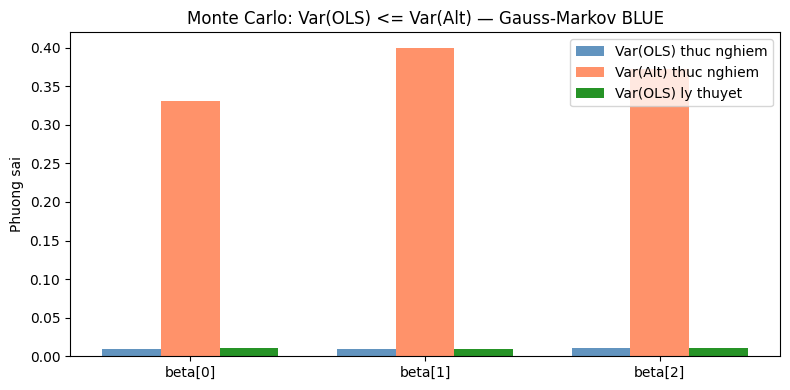

In [47]:
# Bieu do phuong sai OLS vs Alt vs Ly thuyet
fig, ax = plt.subplots(figsize=(8, 4))
k_dim = len(mc['beta_true'])
x_pos = np.arange(k_dim)
w = 0.25
ax.bar(x_pos - w, ols_var, w, label='Var(OLS) thuc nghiem', color='steelblue', alpha=0.85)
ax.bar(x_pos,     alt_var, w, label='Var(Alt) thuc nghiem', color='coral',    alpha=0.85)
ax.bar(x_pos + w, theo_var, w, label='Var(OLS) ly thuyet', color='green',     alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'beta[{j}]' for j in range(k_dim)])
ax.set_ylabel('Phuong sai')
ax.set_title('Monte Carlo: Var(OLS) <= Var(Alt) — Gauss-Markov BLUE')
ax.legend()
plt.tight_layout()
plt.show()


---
## Tóm Tắt

Notebook này đã trình bày toàn bộ nền tảng lý thuyết của Phần 1 và kiểm chứng từng thành phần bằng cách đối chiếu với kết quả từ NumPy. Một số điểm chính:

OLS giải Normal Equations bằng Gauss-Jordan, cho nghiệm không chệch với phương sai nhỏ nhất trong lớp ước lượng tuyến tính — tính chất BLUE được chứng minh bởi Định lý Gauss--Markov và xác nhận qua mô phỏng Monte Carlo. Hat matrix là phép chiếu trực giao lên không gian cột của $\mathbf{X}$; các tính chất idempotent và trace $= p+1$ là hệ quả trực tiếp, sai số máy ở mức $10^{-16}$. Suy luận thống kê — t-test, F-test, VIF — được tính từ đầu không phụ thuộc thư viện. Ridge co hẹp hệ số nhưng không đưa về không; Lasso tạo sparsity thực sự qua soft-thresholding; GCV cho phép chọn $\lambda$ Ridge tự động mà không cần cross-validation rõ ràng. Cross-validation với fold dùng chung là cách đánh giá công bằng nhất khi so sánh nhiều mô hình.